## Heat conduction on a sphere

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, eye
from scipy.sparse.linalg import spsolve

In [2]:
class SphericalHeatCondSolver:
    def __init__(self, N, dt, Bi, omega, theta, t_end):
        self.N = N
        self.dt = dt
        self.Bi = Bi
        self.omega = omega
        self.theta = theta
        self.t_end = t_end

        self.dr = 1 / (self.N-1)
        self.r = np.linspace(0.0, 1.0, N)
        self.alpha = 1.0 - self.dr / 2.0

        self.A = self.build_matrix()
    
    def build_matrix(self):
        N = self.N
        dr = self.dr
        r = self.r
        Bi = self.Bi
        alpha = self.alpha


        # lil_matrix: fast at setting values row-by-row -> later convert to csr_matrix
        A = lil_matrix((N,N))

        # centre row r_1=0
        A[0,0] = -6.0 / (dr**2)
        A[0,1] = 6.0 / (dr**2)

        # interior rows j = 2, ..., N-1
        for i in range(1, N-1):
            rj = r[i]
            c_alpha = ((rj + dr/2.0)**2) / (rj**2)
            c_beta = ((rj - dr/2.0)**2) / (rj**2)

            A[i, i] = -(c_alpha + c_beta) / dr**2
            A[i, i-1] = c_beta / dr**2
            A[i, i+1] = c_alpha / dr**2

        # boundary
        A[N-1, N-2] = (3.0 *alpha**2) / (dr * (1.0 - alpha**3))
        A[N-1, N-1] = - 3.0 * (Bi * dr + alpha**2) / (dr * (1.0 - alpha**3))

        return A
    
    def b(self, t):
        b = np.zeros(self.N)

        b[-1] = 3 * self.Bi * np.sin(self.omega * t) * self.dr / (self.dr * (1.0 - self.alpha**3))
        return b

    
    def solve(self):
        N = self.N
        dt = self.dt
        theta = self.theta
        A = self.A

        nsteps = int(self.t_end / dt) # 0, 1, ..., Nsteps
        times = np.linspace(0.0, nsteps*dt, nsteps +1)

        U = np.zeros((nsteps+1, N))

        # initial condition: u(r_j, 0) = 0 for all j
        u = np.zeros(N)
        U[0,:] = u

        I = eye(N, format= "csr")

        M_left = I - dt * theta * A
        M_right = I + (1-theta) * dt * A

        for n in range(nsteps):
            tn= times[n]
            tn_next = times[n+1]
            bn = self.b(tn)
            bn_next = self.b(tn_next)

            rhs = (M_right @ u + dt * ((1-theta) * bn + theta* bn_next) )

            if theta == 0:
                u = rhs
            else:
                u = spsolve(M_left, rhs)

            U[n+1, :] = u

        return times, self.r, U 

In [3]:
1.0 / (2* (20-1)**2)

0.0013850415512465374

## 1. Compare the three methods

Baseline parameters:
- N= 10
- dt = 0.001
- t_end = 1.0

Starting with:
- omega = 10.0
- Bi = 1.0

### Time evolution at the surface: u(1, t)

In [4]:
1.0//(50**2)

0.0

In [5]:
theta_values = [0.0, 0.5, 1.0]

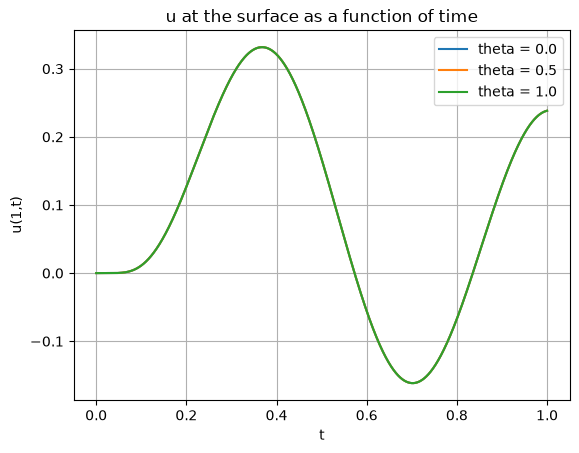

In [6]:
# stability : dt <= dx^2
N = 50
Bi = 1.0
omega = 10.0
dt = 1e-5
t_end = 1.0


for theta in [0.0, 0.5, 1.0]:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()
    
    plt.plot(times, U[:, 0], label=f"theta = {theta}")

plt.xlabel("t")
plt.ylabel("u(1,t)")
plt.title("u at the surface as a function of time")
plt.legend()
plt.grid()
plt.show()

All same behavior. At the surface, mostly oscillating in time bc of oscillatory outside convective fluxes.
I fixed the surface, but u_j(t) has same behavior at every point of the sphere:

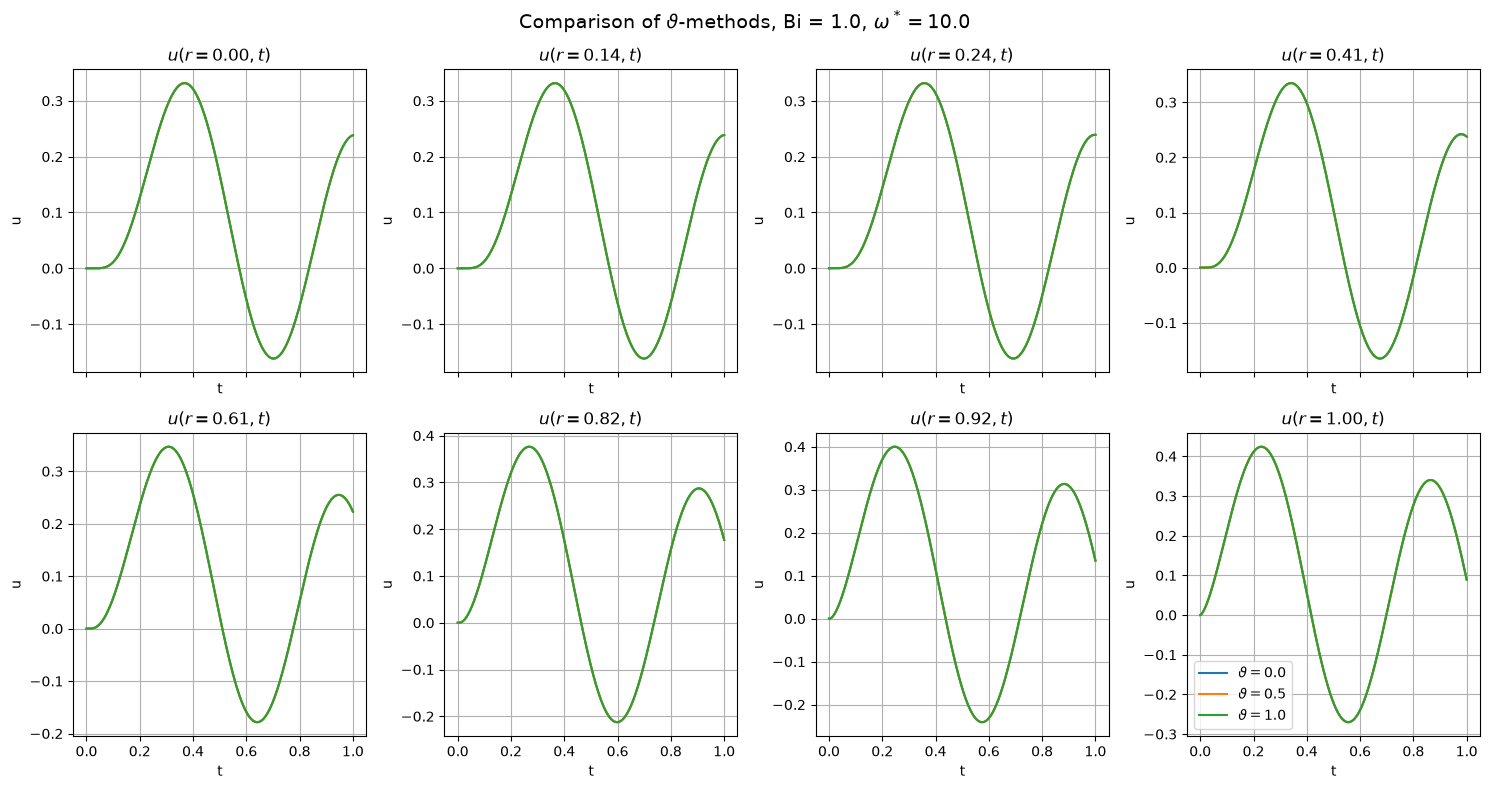

In [7]:
## test many positions on the radius
N = 50
Bi = 1.0
omega = 10.0
dt = 1e-5
t_end = 1.0

radiuses = [0, 7, 12, 20, 30, 40, 45, 49]

fig, axes = plt.subplots(2, 4, figsize=(15, 8), sharex=True)
axes = axes.ravel()

for theta in theta_values:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()

    for k, idx in enumerate(radiuses):
        ax = axes[k]

        ax.plot(times, U[:, idx], label=fr"$\vartheta = {theta}$")
        ax.set_title(fr"$u(r={r[idx]:.2f},t)$")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)

fig.suptitle(
    fr"Comparison of $\vartheta$-methods, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)
plt.legend()
plt.tight_layout()
plt.show()

## Space evolution at different time steps

In [8]:
int(t_end / dt)

99999

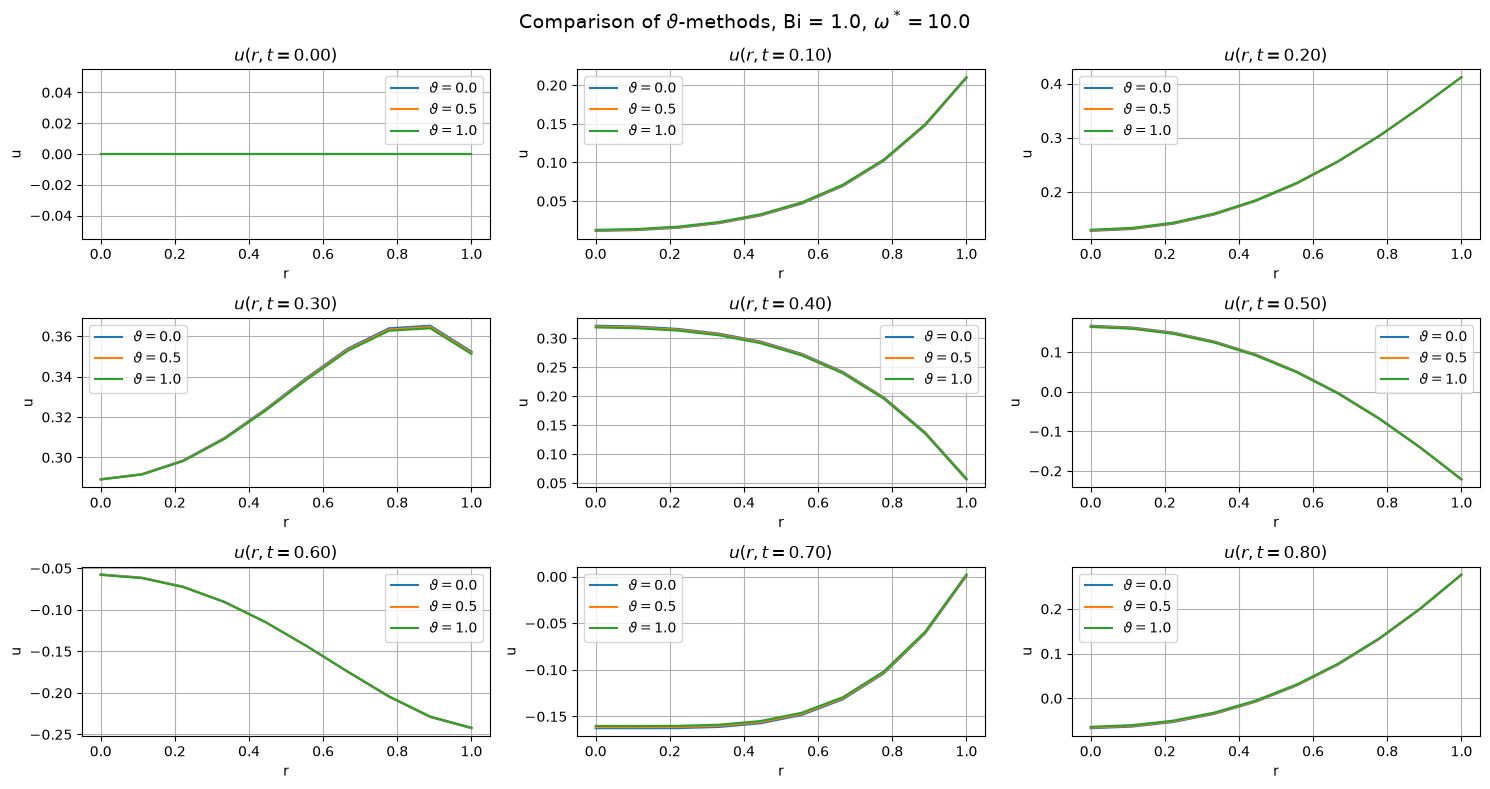

In [25]:
## test many time steps and evaluate u(r, t=tn)
N = 10
Bi = 1.0
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

time_steps = [0, 100, 200, 300, 400, 500, 600, 700, 800]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.ravel()

for theta in theta_values:
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta, t_end)
    times, r, U = solver.solve()

    for k, idx in enumerate(time_steps):
        ax = axes[k]

        ax.plot(r, U[idx, :], label=fr"$\vartheta = {theta}$")
        ax.set_title(fr"$u(r,t={times[idx]:.2f})$")
        ax.set_xlabel("r")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"Comparison of $\vartheta$-methods, Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)

plt.tight_layout()
plt.show()

I watch the solution evolve during the sinusoidal boundary forcing $$\sin(\omega t)$$
So the boundary condition changes sign in time. That is why the profile first positive, then decreasing, then negative, then positive again.
With coarser values of $N$, $dt$, it is possible to see a slight mismatch between the three curves, which is almost imperceptible if the discretization grids are finer. 

## Testing different values of $\vartheta = 0$

### Testing condition for stability:

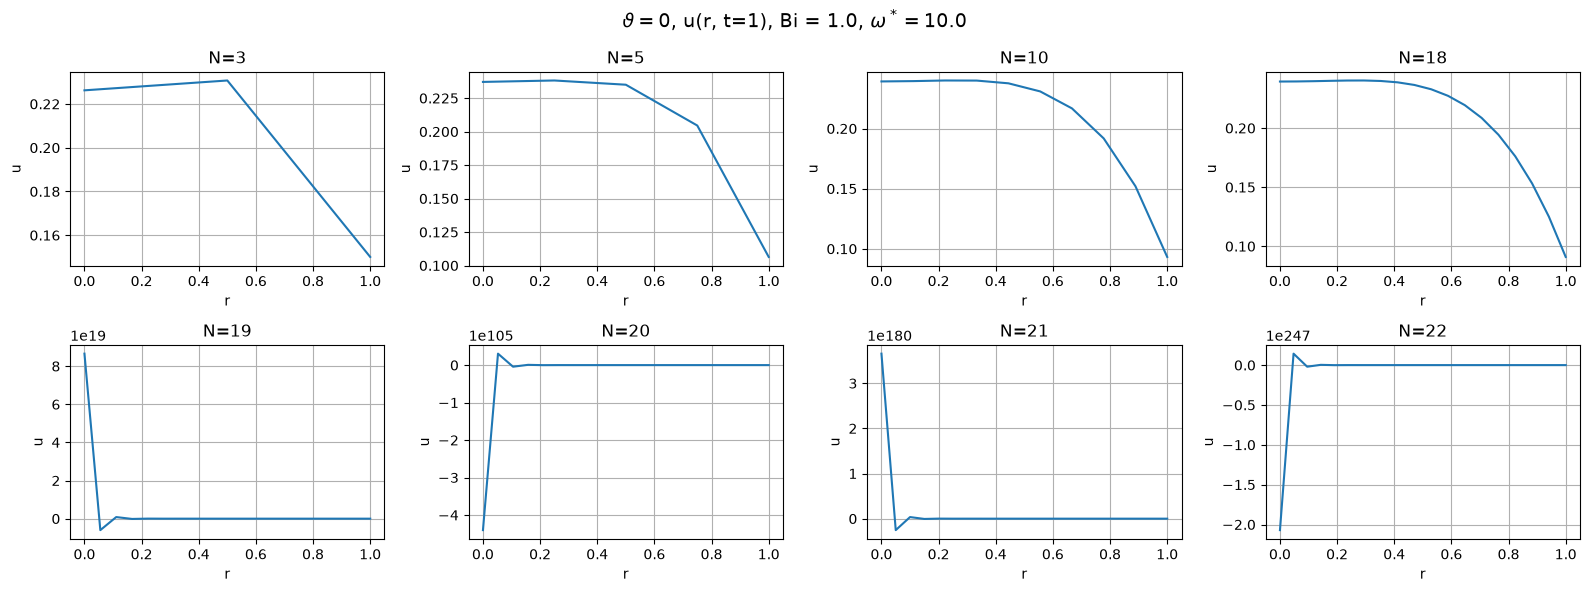

In [10]:
Bi = 1.0
omega = 10.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

N_values = [3, 5, 10, 18, 19, 20, 21, 22]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.ravel()

for k, N in enumerate(N_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    ax = axes[k]
    ax.plot(r, U[-1, :], label=fr"N = {N}")
    ax.set_title(f"{N=}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    #ax.legend()

fig.suptitle(
    fr"$\vartheta=0$, u(r, t=1), Bi = {Bi}, $\omega^* = {omega}$",
    fontsize=14
)

plt.tight_layout()
plt.show()

Explicit Euler condition for stability is $\Delta t \leq \Delta r^2 $, so the time step scales quadratically with the grid step size. Keeping $\Delta t =0.001$, if $N$ becomes too large the stability condition is not satisfied as

$$\Delta r \propto \frac{1}{N}$$

### Different values of $\omega$:

In [11]:
n_timesteps

1000

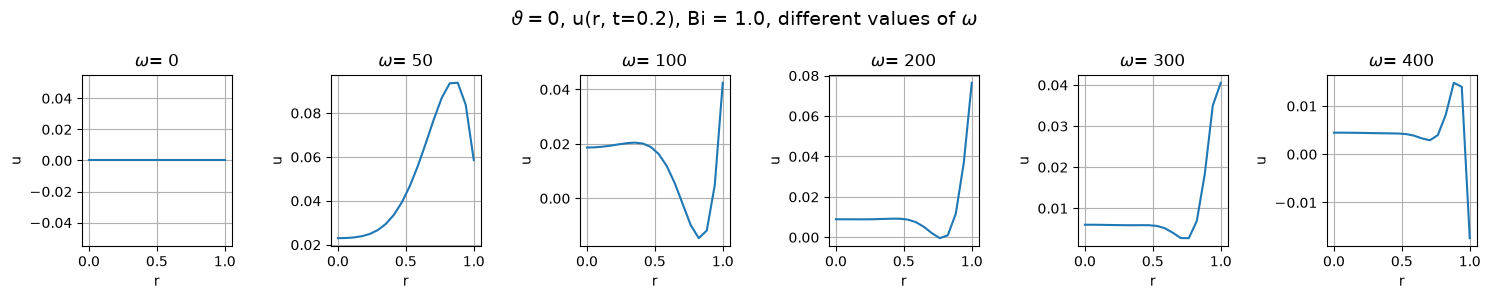

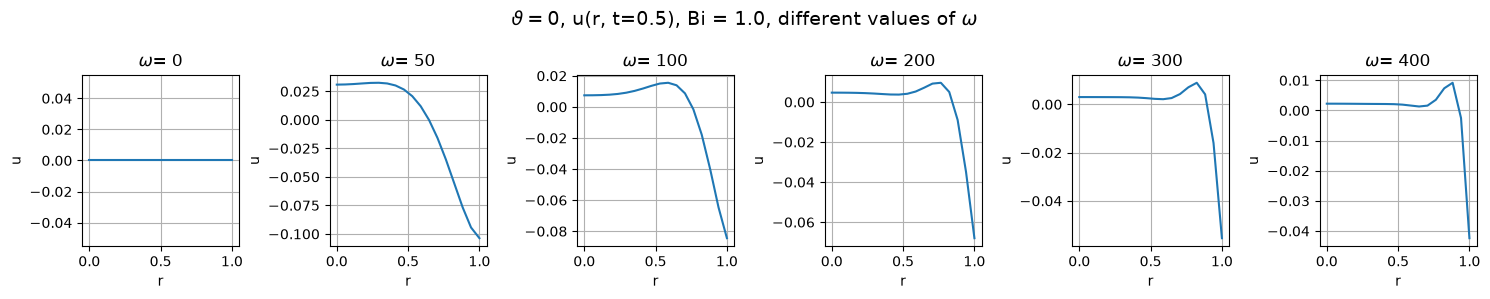

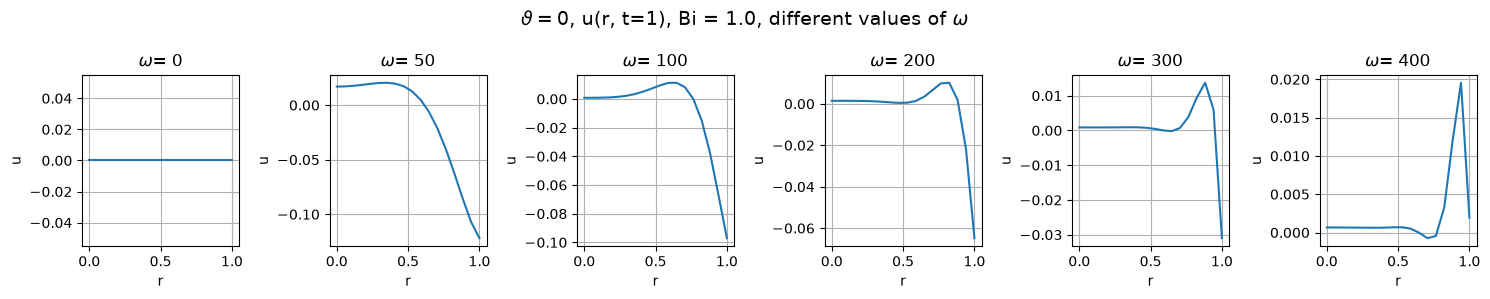

In [26]:
# stable: 
N = 18
Bi = 1.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

omega_values = [0, 50, 100, 200, 300, 400]

## -----------
## t= 0.2
## -----------
fig, axes = plt.subplots(1, len(omega_values), figsize=(15, 3))
axes = axes.ravel()

for k, omega in enumerate(omega_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    ax = axes[k]
    ax.plot(r, U[200, :], label=fr"$\omega$ = {omega}")
    ax.set_title(fr"$\omega$= {omega}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    #ax.legend()

fig.suptitle(
    fr"$\vartheta=0$, u(r, t={times[200]}), Bi = {Bi}, different values of $\omega$",
    fontsize=14
)

plt.tight_layout()
plt.show()


## -----------
## t= 0.5
## -----------
fig, axes = plt.subplots(1, len(omega_values), figsize=(15, 3))
axes = axes.ravel()

for k, omega in enumerate(omega_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    ax = axes[k]
    ax.plot(r, U[500, :], label=fr"$\omega$ = {omega}")
    ax.set_title(fr"$\omega$= {omega}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    #ax.legend()

fig.suptitle(
    fr"$\vartheta=0$, u(r, t={times[500]}), Bi = {Bi}, different values of $\omega$",
    fontsize=14
)

plt.tight_layout()
plt.show()


## -----------
## t= 1
## -----------
fig, axes = plt.subplots(1, len(omega_values), figsize=(15, 3))
axes = axes.ravel()

for k, omega in enumerate(omega_values):
    solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= 0.0, t_end=t_end)
    times, r, U = solver.solve()

    ax = axes[k]
    ax.plot(r, U[-1, :], label=fr"$\omega$ = {omega}")
    ax.set_title(fr"$\omega$= {omega}")
    #ax.set_title(f"$u(r,t)$")
    ax.set_xlabel("r")
    ax.set_ylabel("u")
    ax.grid(True)
    #ax.legend()

fig.suptitle(
    fr"$\vartheta=0$, u(r, t=1), Bi = {Bi}, different values of $\omega$",
    fontsize=14
)

plt.tight_layout()
plt.show()


Goes out of range in case of instability

At the final time step, the value of $u$ near the center remains close to $0$ and approx negative at the surface. 
For larger $\omega$, the external forcing $\sin(\omega t)$ oscillates faster. Near the boundary, it spikes and then drops to the final value at the surface. The higher the value of $\omega$, the more peaked the spike is near the surface. So the frequency of oscillations mostly affects the part of the sphere that is closest to the outside convective currents.

Heat diffusion needs time to transport that oscillation into the interior of the sphere. If the boundary oscillates too quickly, the interior cannot follow it well.

## Testing all $\vartheta$ methods with different values of $\omega$

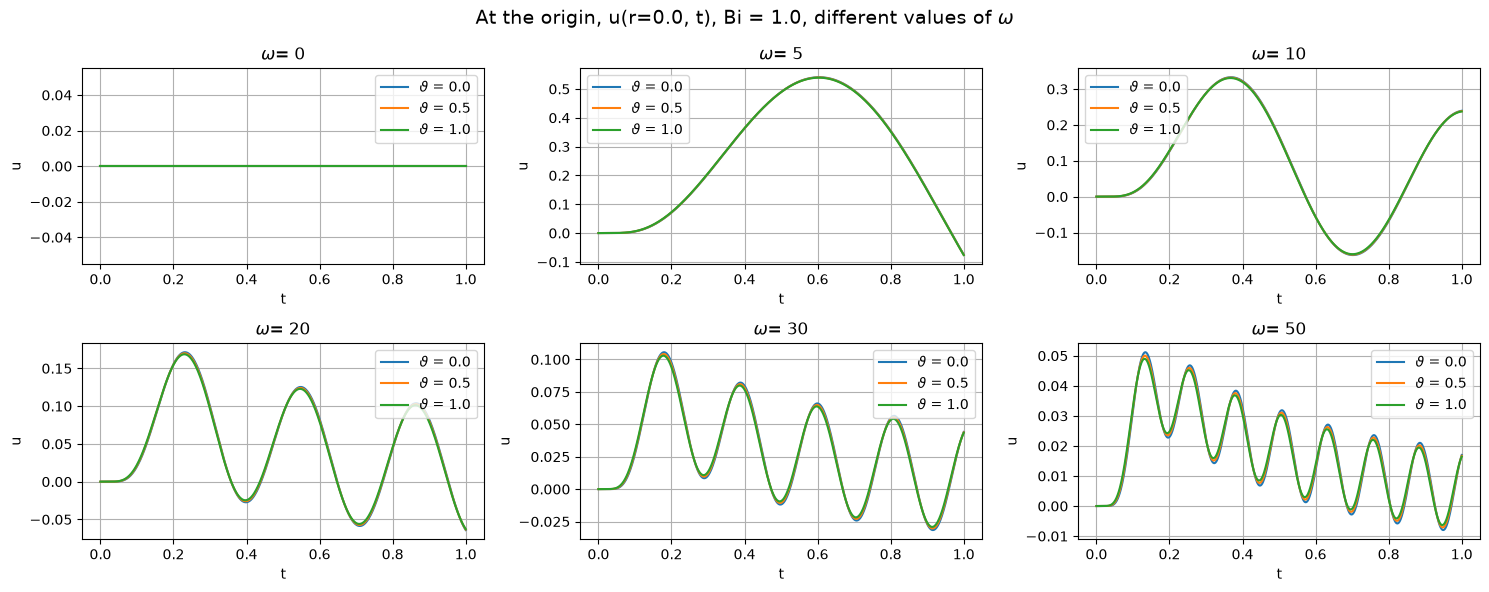

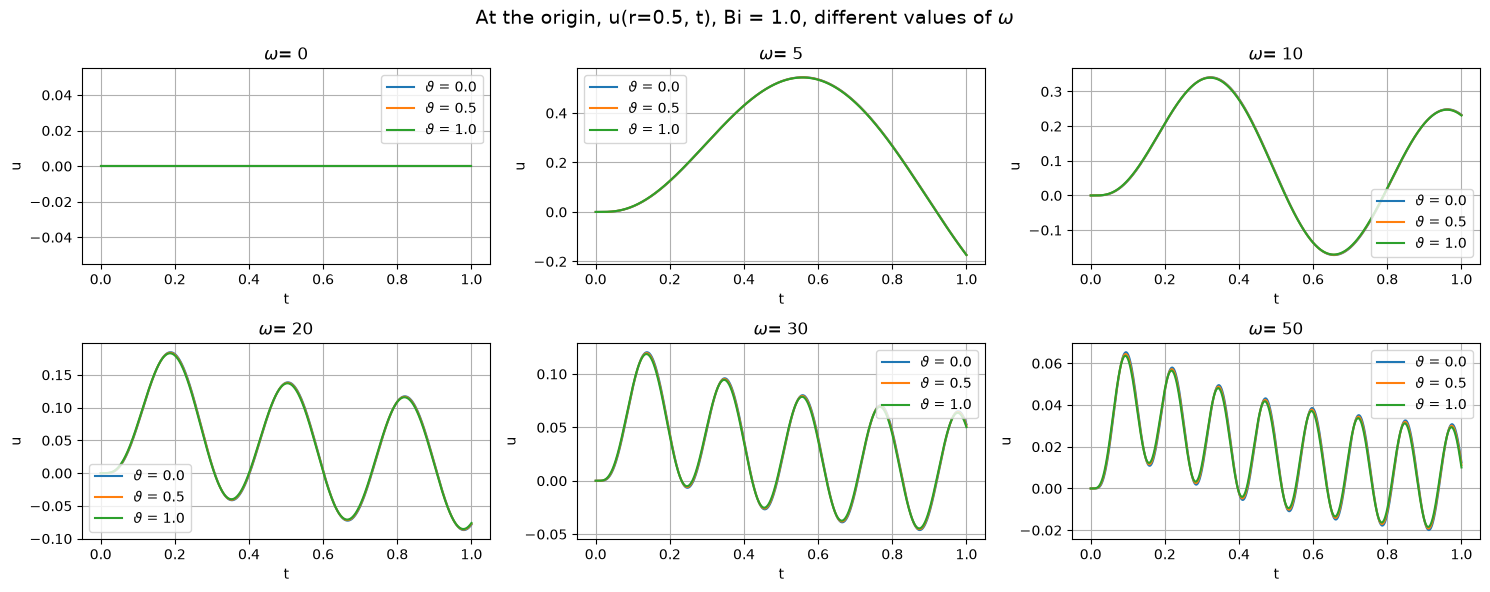

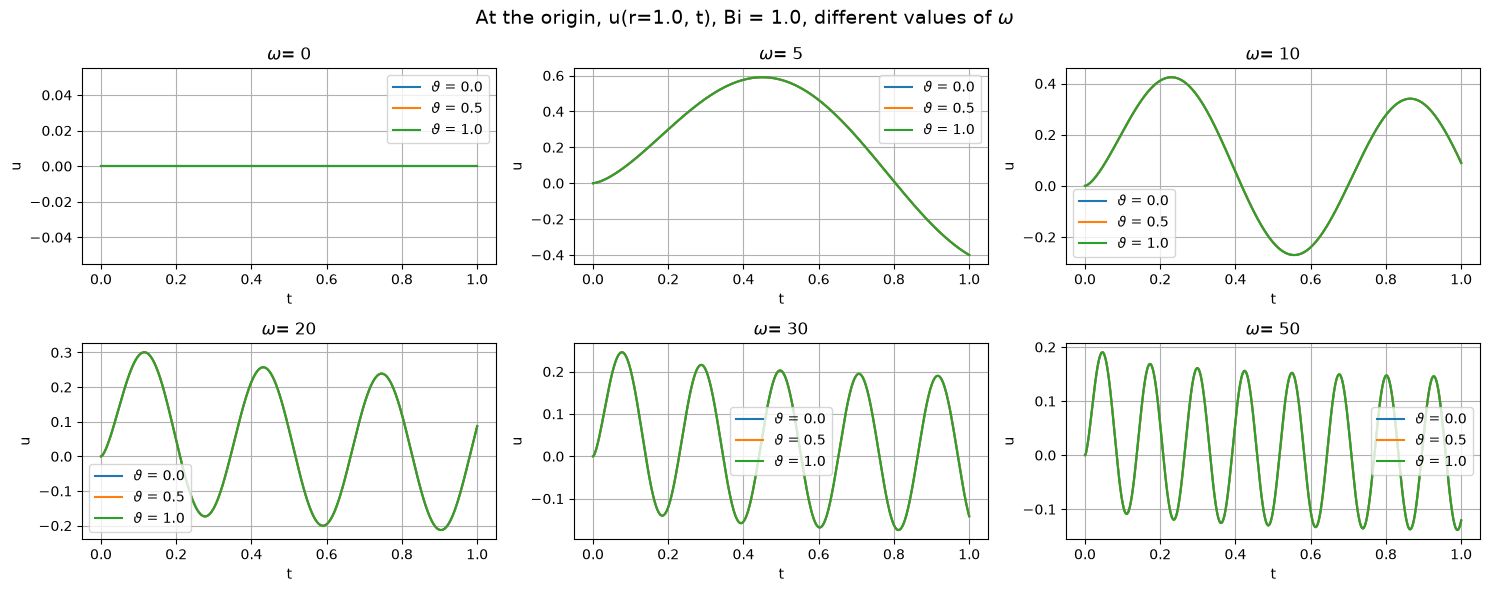

In [30]:
N = 18
Bi = 1.0
dt = 0.001
t_end = 1.0

n_timesteps = int(t_end / dt)

omega_values = [0, 5, 10, 20, 30, 50]
theta_values = [0.0, 0.5, 1.0]
r_dict = {0:0.0, 9:0.5, -1:1.0}

for r_idx, r_value in r_dict.items():
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.ravel()

    for theta in theta_values:
        for k, omega in enumerate(omega_values):
            solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
            times, r, U = solver.solve()

            ax = axes[k]
            ax.plot(times, U[:, r_idx], label= fr"$\vartheta$ = {theta}")
            ax.set_title(fr"$\omega$= {omega}")
            #ax.set_title(f"$u(r,t)$")
            ax.set_xlabel("t")
            ax.set_ylabel("u")
            ax.grid(True)
            ax.legend()

    fig.suptitle(
        fr"At the origin, u(r={r_value}, t), Bi = {Bi}, different values of $\omega$",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

$\omega$ controls the temporal oscillation frequency of $u$, so it is expected that at different radiuses in the sphere, the same oscillating pattern emerges.

However, the amplitude and phase of the response depend on the radius. Points closer to the boundary react more directly, while the centre shows a delayed and damped response, especially for larger values of

Since it is the same for all $\vartheta$, i continue with just $\vartheta=0$

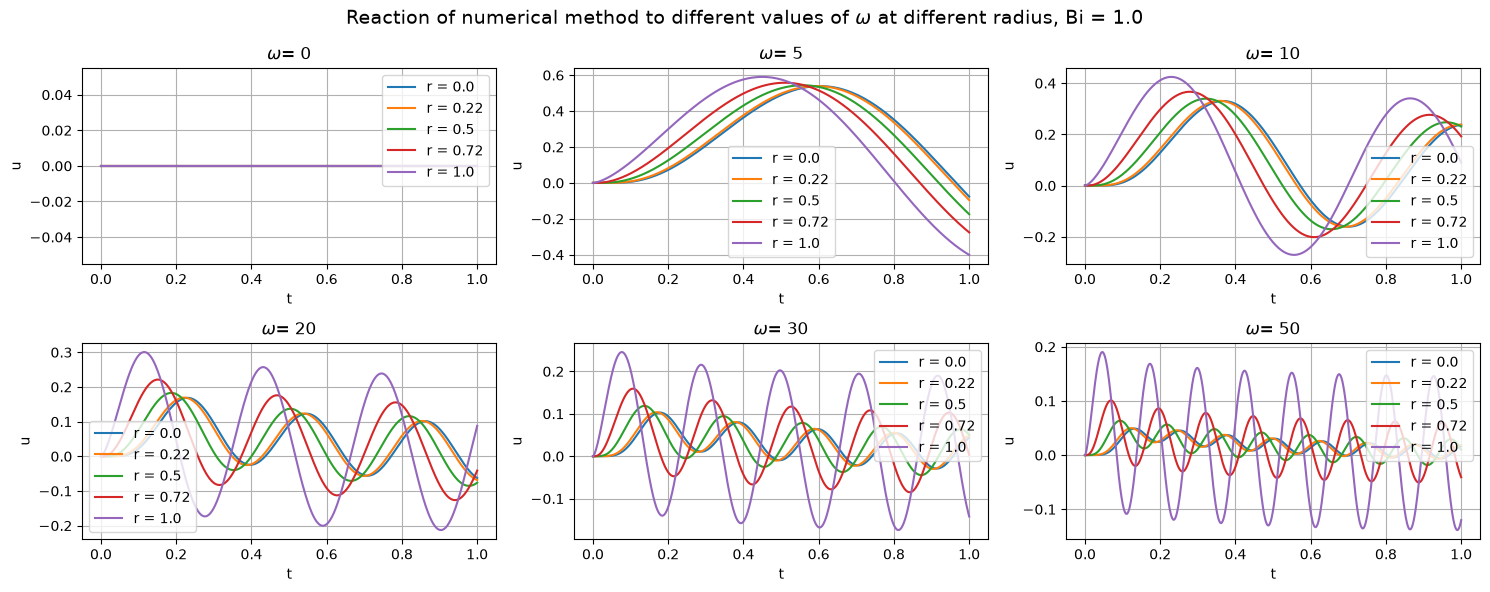

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.ravel()

r_dict= {0:0.0, 4:0.22, 9:0.5, 13:0.72, -1:1.0}

for idx, radius in r_dict.items():
    for k, omega in enumerate(omega_values):
        solver = SphericalHeatCondSolver(N, dt, Bi, omega, theta= theta, t_end=t_end)
        times, r, U = solver.solve()

        ax = axes[k]
        ax.plot(times, U[:, idx], label= fr"r = {radius}")
        ax.set_title(fr"$\omega$= {omega}")
        #ax.set_title(f"$u(r,t)$")
        ax.set_xlabel("t")
        ax.set_ylabel("u")
        ax.grid(True)
        ax.legend()

fig.suptitle(
    fr"Reaction of numerical method to different values of $\omega$ at different radius, Bi = {Bi}",
    fontsize=14
)

plt.tight_layout()
plt.show()